In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movie_df = pd.read_csv('movies.csv')
ratings_df = pd.read_csv('ratings.csv')
links_df = pd.read_csv('links.csv')
tags_df = pd.read_csv('tags.csv')

In [3]:
movie_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
movie_df.tail()

,movieId,title,genres
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation
9741,193609,Andrew Dice Clay: Dice Rules (1991),Comedy


In [5]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
ratings_df.tail()

,userId,movieId,rating,timestamp
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352
100835,610,170875,3.0,1493846415


In [7]:
links_df.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [8]:
links_df.tail()

,movieId,imdbId,tmdbId
9737,193581,5476944,432131.0
9738,193583,5914996,445030.0
9739,193585,6397426,479308.0
9740,193587,8391976,483455.0
9741,193609,101726,37891.0


In [9]:
tags_df.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [10]:
tags_df.tail()

,userId,movieId,tag,timestamp
3678,606,7382,for katie,1171234019
3679,606,7936,austere,1173392334
3680,610,3265,gun fu,1493843984
3681,610,3265,heroic bloodshed,1493843978
3682,610,168248,Heroic Bloodshed,1493844270


In [11]:
print(movie_df.shape)
print(ratings_df.shape)
print(links_df.shape)
print(tags_df.shape)

(9742, 3)
(100836, 4)
(9742, 3)
(3683, 4)


In [12]:
df = ratings_df.merge(movie_df, on="movieId", how="left")

In [13]:
df = df.merge(links_df, on="movieId", how="left")


In [14]:
movie_tags = tags_df.groupby('movieId')['tag'].apply(lambda x: '|'.join(x.astype(str))).reset_index()
df = df.merge(movie_tags, on="movieId", how="left")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
 6   imdbId     100836 non-null  int64  
 7   tmdbId     100823 non-null  float64
 8   tag        48287 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 6.9+ MB


In [16]:
df.head()

,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,tag
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,pixar|pixar|fun
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,moldy|old
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,113277,949.0,NaN
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,mystery|twist ending|serial killer
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,mindfuck|suspense|thriller|tricky|twist ending...


In [17]:
df.tail()

,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,tag
100831,610,166534,4.0,1493848402,Split (2017),Drama|Horror|Thriller,4972582,381288.0,NaN
100832,610,168248,5.0,1493850091,John Wick: Chapter Two (2017),Action|Crime|Thriller,4425200,324552.0,action|dark hero|gun tactics|hitman|Keanu Reev...
100833,610,168250,5.0,1494273047,Get Out (2017),Horror,5052448,419430.0,NaN
100834,610,168252,5.0,1493846352,Logan (2017),Action|Sci-Fi,3315342,263115.0,dark|emotional|gritty|heartbreaking|predictibl...
100835,610,170875,3.0,1493846415,The Fate of the Furious (2017),Action|Crime|Drama|Thriller,4630562,337339.0,NaN


In [18]:
df.isnull().sum()

userId           0
movieId          0
rating           0
timestamp        0
title            0
genres           0
imdbId           0
tmdbId          13
tag          52549
dtype: int64

In [19]:
df["tag"] = df["tag"].fillna("no_tag")

In [20]:
df.isnull().sum()

userId        0
movieId       0
rating        0
timestamp     0
title         0
genres        0
imdbId        0
tmdbId       13
tag           0
dtype: int64

In [21]:
df.dropna(inplace=True)

a very few number of missing values in tmbID, hence dropping these.

In [22]:
df.shape

(100823, 9)

In [23]:
df.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
imdbId       0
tmdbId       0
tag          0
dtype: int64

In [24]:
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
df["year"] = df["timestamp"].dt.year

In the README.txt it mentioned that that the timestamp represents seconds since midnight Coordinated Universal Time (UTC) of January 1, 1970. so i did a quick google search and implement unit="s" to convert it into proper date and time.

In [25]:
df.head()

,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,tag,year
0,1,1,4.0,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,pixar|pixar|fun,2000
1,1,3,4.0,2000-07-30 18:20:47,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,moldy|old,2000
2,1,6,4.0,2000-07-30 18:37:04,Heat (1995),Action|Crime|Thriller,113277,949.0,no_tag,2000
3,1,47,5.0,2000-07-30 19:03:35,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,mystery|twist ending|serial killer,2000
4,1,50,5.0,2000-07-30 18:48:51,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,mindfuck|suspense|thriller|tricky|twist ending...,2000


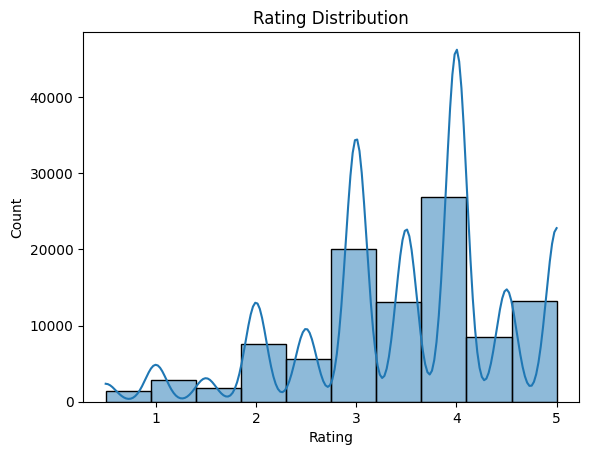

In [26]:
plt.figure()
sns.histplot(df["rating"], bins=10, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


Most movies are rated between 3.75 and 4 

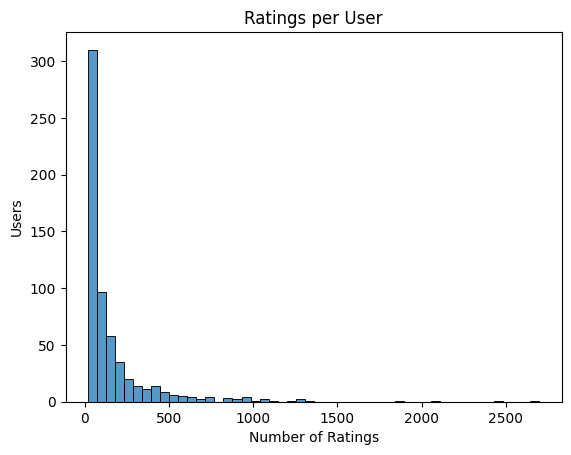

count     610.000000
mean      165.283607
std       269.443981
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
Name: rating, dtype: float64


In [27]:
user_activity = df.groupby("userId")["rating"].count()

plt.figure()
sns.histplot(user_activity, bins=50)
plt.title("Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Users")
plt.show()

print(user_activity.describe())


In [28]:
movie_popularity = df.groupby("title")["rating"].count().sort_values(ascending=False)

print(movie_popularity.head(10))


title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64


Movies with the highest ratings.

In [37]:
df.groupby('title')['rating'].mean().sort_values(ascending=False)

title
Scooby-Doo! and the Loch Ness Monster (2004)           5.0
'Salem's Lot (2004)                                    5.0
Ex Drummer (2007)                                      5.0
I, the Jury (1982)                                     5.0
Ice Age: The Great Egg-Scapade (2016)                  5.0
                                                      ... 
I Know Who Killed Me (2007)                            0.5
Pokemon 4 Ever (a.k.a. Pokémon 4: The Movie) (2002)    0.5
Idaho Transfer (1973)                                  0.5
Mortal Kombat: The Journey Begins (1995)               0.5
Survivor (2015)                                        0.5
Name: rating, Length: 9713, dtype: float64

List of highest rated movies

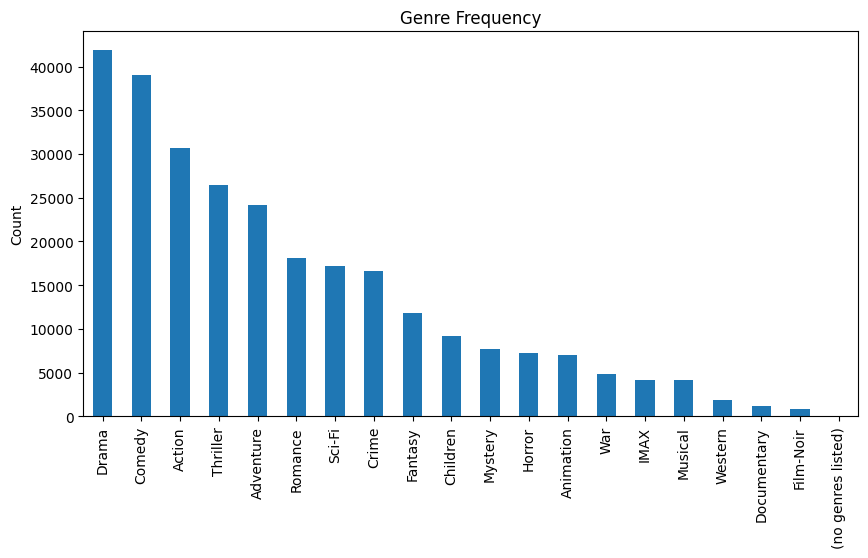

In [ ]:
genres_expanded = df["genres"].str.get_dummies("|")
genre_counts = genres_expanded.sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

genre_counts.plot(kind="bar")
plt.title("Genre Frequency")
plt.ylabel("Count")
plt.show()


Most of the movie genres being drama, comedy and action.

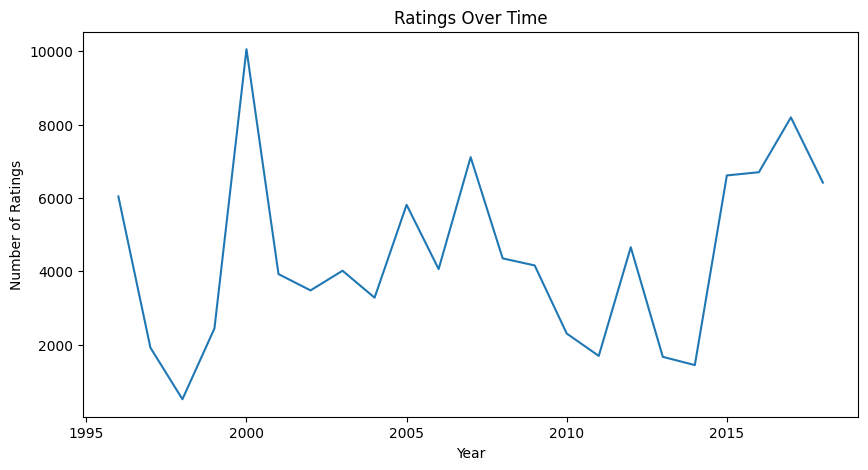

In [31]:
ratings_per_year = df.groupby("year")["rating"].count()

plt.figure(figsize=(10,5))
ratings_per_year.plot()
plt.title("Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.show()


Number of ratings peaking between the years 1998 to 2000.

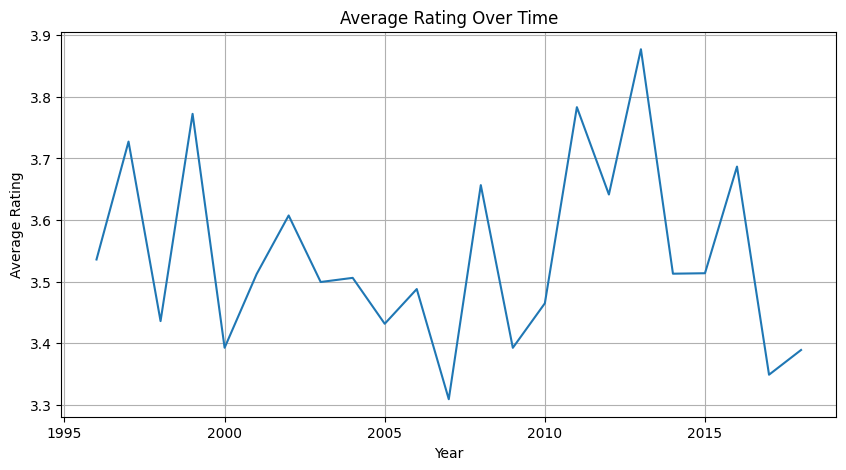

In [32]:
avg_rating_year = df.groupby("year")["rating"].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_rating_year.index, avg_rating_year.values)
plt.title("Average Rating Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()


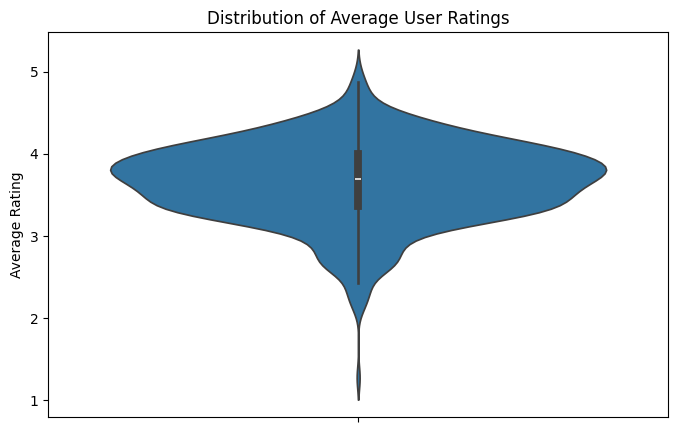

In [33]:
user_avg = df.groupby("userId")["rating"].mean()

plt.figure(figsize=(8,5))
sns.violinplot(y=user_avg)
plt.title("Distribution of Average User Ratings")
plt.ylabel("Average Rating")
plt.show()


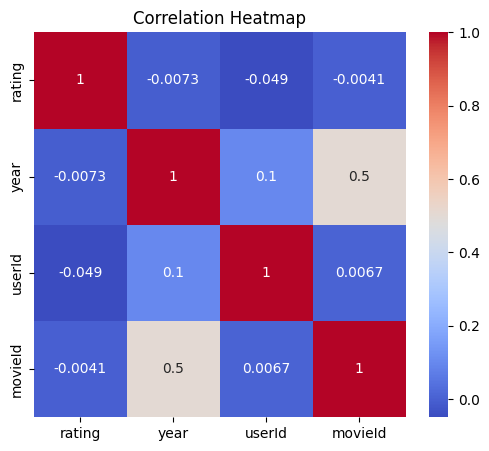

In [34]:
corr = df[["rating", "year", "userId", "movieId"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


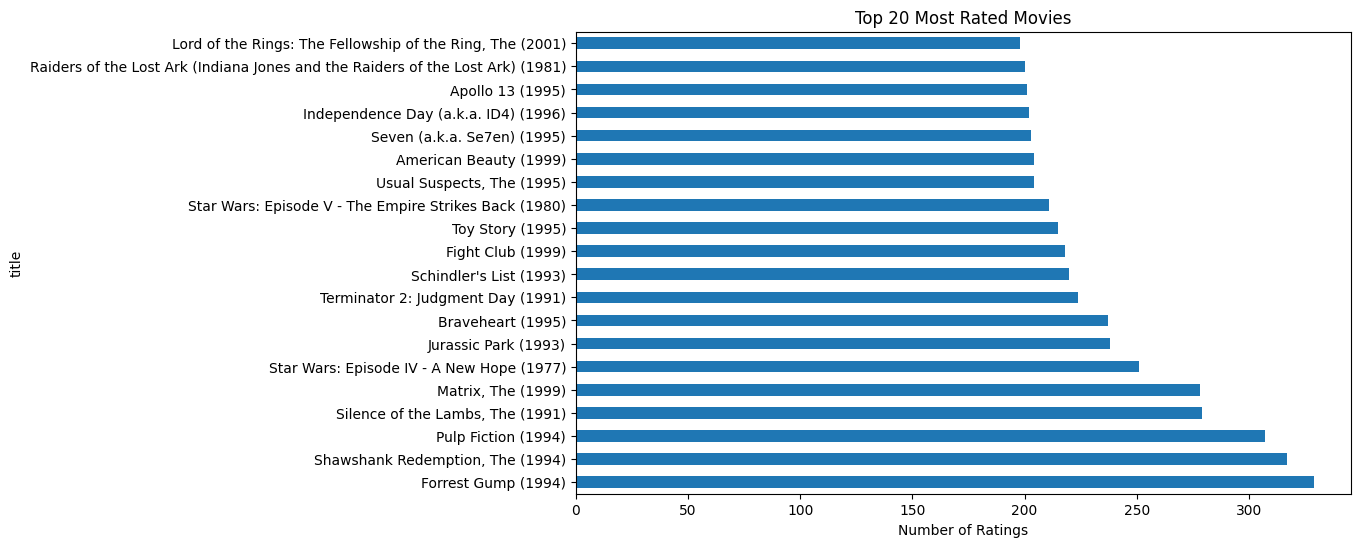

In [35]:
top_movies = df["title"].value_counts().head(20)

plt.figure(figsize=(10,6))
top_movies.plot(kind="barh")
plt.title("Top 20 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.show()


List of top 20 popular movies starting with Forrest Gump (1994).

The proposed solution is a movie recommendation system.
We would use the ratings data to suggest movies to users with similar favourite genres.
We can use the genres and tags column to find movies with similar ones to a user already likes.


My proposed solution is to use KNN to recommend movies. Similiarity bw movies can be calculated using metric like cosine similarity.